# Generate model predictions on occlusion dataset

## Set up env

Hyperparameters

In [ ]:
# prompt: add a choice param for which dataset it was pretrained on mnist or kth or bair

pretraining_dataset = "kth" #@param ["mnist", "kth", "bair"]

# # Load model
#
# For now, we are using a pretrained [PredRNN-V2](https://github.com/thuml/predrnn-pytorch) model.
# Now using the selected dataset: {dataset}

imports

In [ ]:
import torch
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import Image as IPyImage

## Load data

In [ ]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/intuitive physics/data" /content/
!ls data

ls: cannot access 'data': No such file or directory


In [ ]:
!pwd

/content/predrnn-pytorch


In [ ]:
data_dir = Path("/content/data")
scene_dir = data_dir / "occlusion_experiments" / "scene_c2955662"
frame_dir = scene_dir / "frames"
frame_data_path = scene_dir / "frame_data.csv"
scene_gif_path = scene_dir / "scene.gif"
scene_metadata_path = scene_dir / "scene_metadata.json"

assert scene_dir.exists()
assert frame_dir.exists()
assert frame_data_path.exists()
assert scene_gif_path.exists()
assert scene_metadata_path.exists()

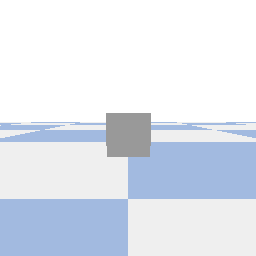

In [ ]:
IPyImage(filename=scene_gif_path)

In [ ]:
print(f"Found {len(list(frame_dir.glob('*.png')))} frames")

Found 150 frames


In [ ]:
with open(scene_metadata_path, 'r') as f:
    scene_metadata = json.load(f)
scene_metadata

{'gif_path': 'scene.gif',
 'ball_start': [-1.0, 0, 0.05],
 'force_vector': [100, 0, 0],
 'barrier_position': [0.0, 0, 0.1],
 'barrier_half_width': 0.1,
 'ball_radius': 0.05,
 'frame_count': 150,
 'fps': 10,
 'image_size': 256,
 'camera_eye_position': [0.0, -1.5, 0.2],
 'camera_target_position': [0.0, 0.0, 0.1],
 'scene_id': 'scene_c2955662',
 'occlusion_start_frame': 56,
 'occlusion_end_frame': 82,
 'visible_before_occlusion_frames': 56,
 'reappearance_frame': 83}

In [ ]:
frame_data_df = pd.read_csv(frame_data_path)
frame_data_df

,frame,x,y,z,vx,vy,vz,occluded
0,0,-0.982639,0.000000e+00,0.049490,4.166667,0.000000e+00,-8.166667e-02,False
1,1,-0.965278,0.000000e+00,0.048979,4.166667,0.000000e+00,-1.225000e-01,False
2,2,-0.947917,0.000000e+00,0.048299,4.166667,0.000000e+00,-1.633333e-01,False
3,3,-0.930556,0.000000e+00,0.047448,4.166667,0.000000e+00,-2.041667e-01,False
4,4,-0.913194,0.000000e+00,0.046427,4.166667,0.000000e+00,-2.450000e-01,False
...,...,...,...,...,...,...,...,...
145,145,0.619342,-2.842747e-13,0.029990,1.165417,-4.228126e-13,1.408459e-07,False
146,146,0.624113,-2.860652e-13,0.029990,1.145000,-4.297197e-13,1.295784e-07,False
147,147,0.628798,-2.878421e-13,0.029990,1.124583,-4.264562e-13,1.192120e-07,False
148,148,0.633399,-2.896837e-13,0.029990,1.104167,-4.419730e-13,1.096751e-07,False


In [ ]:
occluded_frames_df = frame_data_df.loc[frame_data_df.occluded]
occlusion_start = occluded_frames_df["frame"].min()
occlusion_end = occluded_frames_df["frame"].max()
print(f"Occlusion starts at frame {occlusion_start} and ends at frame {occlusion_end}")

Occlusion starts at frame 56 and ends at frame 82


## Load model

In [ ]:
!git clone https://github.com/thuml/predrnn-pytorch.git
%cd predrnn-pytorch
!pip install -q gdown
!mkdir -p checkpoints

# MNIST model
!gdown 1xZT_KYZDGg7JCXotp-rG6KaANNmybfiX -O checkpoints/mnist_model.ckpt

# KTH model
!gdown 1h0ngXMbOxtEJxRVG0Isj6ecfaIqhRdKr -O checkpoints/kth_model.ckpt

# BAIR model
!gdown 1g5WvaAtW9rjYhP94ohZXFyqLgj7jpRzg -O checkpoints/bair_model.ckpt

Cloning into 'predrnn-pytorch'...
remote: Enumerating objects: 474, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 474 (delta 105), reused 86 (delta 86), pack-reused 350 (from 1)
Receiving objects: 100% (474/474), 27.57 MiB | 38.25 MiB/s, done.
Resolving deltas: 100% (233/233), done.
/content/predrnn-pytorch/predrnn-pytorch
Downloading...
From: https://drive.google.com/uc?id=1xZT_KYZDGg7JCXotp-rG6KaANNmybfiX
To: /content/predrnn-pytorch/predrnn-pytorch/checkpoints/mnist_model.ckpt
100% 95.4M/95.4M [00:03<00:00, 24.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1h0ngXMbOxtEJxRVG0Isj6ecfaIqhRdKr
From (redirected): https://drive.google.com/uc?id=1h0ngXMbOxtEJxRVG0Isj6ecfaIqhRdKr&confirm=t&uuid=82ce6dd8-382b-4104-9f98-1bc95a6844ee
To: /content/predrnn-pytorch/predrnn-pytorch/checkpoints/kth_model.ckpt
100% 95.4M/95.4M [00:03<00:00, 30.3MB/s]
Downloading...
From (original): https://drive.google.com/

In [ ]:
import numpy as np
import torch
from core.models.model_factory import Model
from core.utils.preprocess import reshape_patch, reshape_patch_back

In [ ]:
class Configs:
    def __init__(self):
        # Defaults
        self.model_name = 'predrnn_v2'
        self.num_hidden = '128,128,128,128'
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.input_length = 10
        self.total_length = 20
        self.patch_size = 4
        self.layer_norm = False
        self.reverse_input = True
        self.model_path = None
        self.batch_size = 4
        self.save_dir = 'checkpoints'
        self.lr = 0.0001

        # Required by model
        self.visual = False
        self.visual_path = './visual'
        self.filter_size = 5
        self.stride = 1
        self.reverse_scheduled_sampling = True
        self.r_sampling_step_1 = 5000
        self.r_sampling_step_2 = 50000
        self.r_exp_alpha = 2000

        # Dataset-specific extras
        self.conv_on_input = False
        self.res_on_conv = False
        self.decouple_beta = 0.0
        self.img_width = 64
        self.img_channel = 1

    @classmethod
    def from_dataset(cls, name: str) -> 'Configs':
        cfg = cls()
        if name == 'mnist':
            cfg.img_width = 64
            cfg.img_channel = 1
            cfg.decouple_beta = 0.1
            cfg.batch_size = 8
            cfg.r_sampling_step_1 = 25000
            cfg.r_exp_alpha = 2500
        elif name == 'kth':
            cfg.img_width = 128
            cfg.img_channel = 1
            cfg.decouple_beta = 0.01
        elif name == 'bair':
            cfg.model_name = 'action_cond_predrnn_v2'
            cfg.img_width = 64
            cfg.img_channel = 3
            cfg.input_length = 2
            cfg.total_length = 12
            cfg.patch_size = 1
            cfg.batch_size = 16
            cfg.decouple_beta = 0.1
            cfg.conv_on_input = True
            cfg.res_on_conv = True
            cfg.r_sampling_step_1 = 25000
            cfg.r_exp_alpha = 2500
            cfg.num_action_ch = 4
        else:
            raise ValueError(f"Unsupported dataset: {name}")
        return cfg

In [ ]:
# -----------------------------------
# Create model
# -----------------------------------
if pretraining_dataset == "mnist":
    configs = Configs.from_dataset('mnist')
elif pretraining_dataset == "kth":
    configs = Configs.from_dataset('kth')
elif pretraining_dataset == "bair":
    configs = Configs.from_dataset('bair')
else:
    raise ValueError(f"Unsupported dataset: {pretraining_dataset}")

model = Model(configs)
# model.network.eval()
# Load checkpoint
model.load(f'checkpoints/{pretraining_dataset}_model.ckpt')

load model: checkpoints/kth_model.ckpt


## Generate predictions

In [ ]:
_, T, H, W, C = configs.batch_size, configs.total_length, configs.img_width, configs.img_width, configs.img_channel
T, H, W, C

(20, 128, 128, 1)

In [ ]:
def extract_sequence_including_occlusion_as_conditioning(
    start_occ: int,
    end_occ: int,
    T: int = 16,
    T_cond: int = 8,
    subsample: int = 2,
) -> dict:
    """
    Returns frame indices where the conditioning includes all occlusion frames,
    and prediction starts after the occlusion ends. All indices are subsampled.

    Args:
        start_occ (int): First occlusion frame.
        end_occ (int): Last occlusion frame.
        T (int): Total number of frames in the sequence.
        T_cond (int): Number of conditioning frames (including occlusion).
        subsample (int): Subsampling rate (e.g., 2 = every 2nd frame).

    Returns:
        dict with:
            'conditioning_indices': list of indices for conditioning frames,
            'prediction_indices': list of indices for prediction frames,
            'all_indices': combined list of indices.
    """
    occlusion_indices = list(range(start_occ, end_occ + 1, subsample))
    n_occ = len(occlusion_indices)

    if n_occ > T_cond:
        raise ValueError("Occlusion spans more frames than T_cond allows.")

    n_pre = T_cond - n_occ
    pre_start = start_occ - n_pre * subsample
    if pre_start < 0:
        raise ValueError("Not enough frames before occlusion to satisfy conditioning length.")

    pre_indices = list(range(pre_start, start_occ, subsample))
    conditioning_indices = pre_indices + occlusion_indices

    pred_start = end_occ + subsample
    pred_indices = list(range(pred_start, pred_start + (T - T_cond) * subsample, subsample))

    all_indices = conditioning_indices + pred_indices

    return {
        "conditioning_indices": conditioning_indices,
        "prediction_indices": pred_indices,
        "all_indices": all_indices,
    }


ind_data = extract_sequence_including_occlusion_as_conditioning(start_occ=occlusion_start, end_occ=occlusion_end, T=T, T_cond=configs.input_length, subsample=6)
print(ind_data)
len(ind_data["conditioning_indices"]), len(ind_data["prediction_indices"]), len(ind_data["all_indices"])

{'conditioning_indices': [26, 32, 38, 44, 50, 56, 62, 68, 74, 80], 'prediction_indices': [88, 94, 100, 106, 112, 118, 124, 130, 136, 142], 'all_indices': [26, 32, 38, 44, 50, 56, 62, 68, 74, 80, 88, 94, 100, 106, 112, 118, 124, 130, 136, 142]}


(10, 10, 20)

In [ ]:
import os
from PIL import Image
from torchvision import transforms
import torch

# Define the directory and the transformation
img_dir = frame_dir

frame_size = (H, W)  # (H, W)
T = T                   # frames per video
# transform = transforms.Compose([
#     transforms.Resize(frame_size),
#     transforms.Grayscale(num_output_channels=C),  # convert to grayscale with 1 channel
#     transforms.ToTensor(),  # gives [C, H, W]
# ])

# Load all frames, sort to preserve temporal order
frame_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])
frame_files = [frame_files[i] for i in ind_data["all_indices"]]

N = len(frame_files)
assert N % T == 0, "Number of frames must be divisible by T"
B = N // T

# Load and transform all frames
frames = []
for file in frame_files:
    img = Image.open(os.path.join(img_dir, file)).convert('L')

    # frame_im = Image.open(frame.file_path).convert('L') # int8 2D array

    # input type must be float32 for default interpolation method cv2.INTER_AREA
    frame_np = np.array(img, dtype=np.uint8)  # (1000, 1000) numpy array
    tensor = (cv2.resize(frame_np, frame_size)/255.0).astype(np.float32)

    # tensor = transform(img).permute(1, 2, 0)  # [C, H, W] -> [H, W, C]
    tensor = torch.from_numpy(tensor).unsqueeze(2)
    frames.append(tensor)

# Stack into [N, H, W, C]
video_tensor = torch.stack(frames)

# Reshape to [B, T, H, W, C]
video_tensor = video_tensor.view(B, T, *video_tensor.shape[1:])
video_tensor.shape, video_tensor.min(), video_tensor.max(), video_tensor.dtype

(torch.Size([1, 20, 128, 128, 1]), tensor(0.), tensor(1.), torch.float32)

In [ ]:
# Patchify input [B, T, H, W, C] → [B, T, patch*C, H//p, W//p]
patch_ims = reshape_patch(video_tensor, configs.patch_size)

# Convert patchified input to torch tensor
frames = patch_ims.to(configs.device)

# Run forward pass through the network
model.network.eval()
with torch.no_grad():
    input_length = configs.input_length
    total_length = configs.total_length

    # Construct a mask of shape [batch, total_length - 1, H, W, C]
    # where t < input_length -> 1 (use GT), else -> 0 (use prediction)
    mask_true = torch.zeros_like(frames[:, 1:])
    mask_true[:, :input_length - 1] = 1  # We shift since frames_tensor[:, 1:] aligns with t=1 onward

    pred_patches, _ = model.network(frames, mask_true)


# Convert prediction back from patches
pred_np = pred_patches.cpu().numpy()  # [B, T-1, H//p, W//p, patch*C]
pred_frames = reshape_patch_back(pred_np, configs.patch_size)  # [B, T-1, H, W, C]

print("Predicted frame shape:", pred_frames.shape)  # Expect (B, T-1, H, W, C)
pred_frames.min(), pred_frames.max()

Predicted frame shape: (1, 19, 128, 128, 1)


(np.float32(0.3581827), np.float32(1.021805))

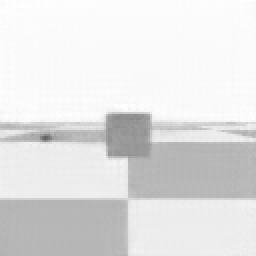

In [ ]:
from PIL import Image
import imageio.v2 as imageio
import numpy as np
import cv2

def save_gif_pil(arr, path='output.gif', fps=10, scale=2):
    arr = np.clip(arr, 0.0, 1.0)
    frames = []

    for t in range(arr.shape[0]):  # [T, H, W]
        frame = (arr[t] * 255).astype(np.uint8)
        img = Image.fromarray(frame)

        if scale != 1:
            w, h = img.size
            img = img.resize((w * scale, h * scale), resample=Image.NEAREST)

        img = img.convert('P', palette=Image.ADAPTIVE)  # optimize palette
        frames.append(img)

    frames[0].save(path, save_all=True, append_images=frames[1:], duration=int(1000/fps), loop=0)


output_path = "/content/prediction.gif"
frames_for_gif = pred_frames[0, :, :, :, 0]  # [T, H, W]
save_gif_pil(frames_for_gif, path=output_path, fps=scene_metadata["fps"]//4, scale=2)
IPyImage(output_path)

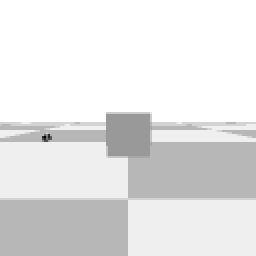

In [ ]:
output_path = "/content/gt.gif"
frames_for_gif = video_tensor[0, :, :, :, 0].numpy()  # [T, H, W]
save_gif_pil(frames_for_gif, path=output_path, fps=scene_metadata["fps"]//4, scale=2)
IPyImage(output_path)

debugging

Predicted frame shape: (1, 19, 128, 128, 1)
Predicted min: 0.3581827
Predicted max: 1.021805


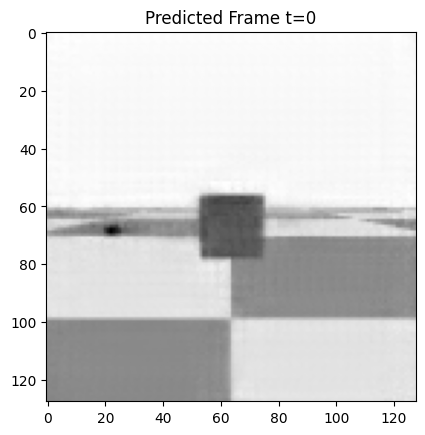

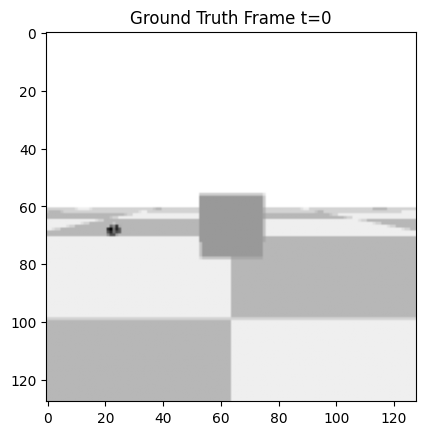

In [ ]:
print("Predicted frame shape:", pred_frames.shape)
print("Predicted min:", pred_frames.min())
print("Predicted max:", pred_frames.max())

import matplotlib.pyplot as plt
t = 0
plt.imshow(np.clip(pred_frames[0, t, :, :, 0], 0, 1), cmap='gray')
plt.title(f"Predicted Frame t={t}")
plt.show()

plt.imshow(video_tensor[0, t, :, :, 0].cpu(), cmap='gray')
plt.title(f"Ground Truth Frame t={t}")
plt.show()

Predicted frame shape: (1, 19, 128, 128, 1)
Predicted min: 0.3581827
Predicted max: 1.021805


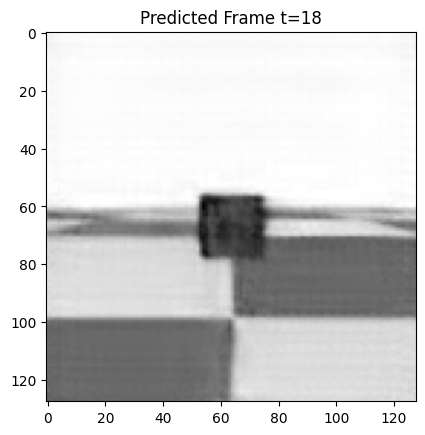

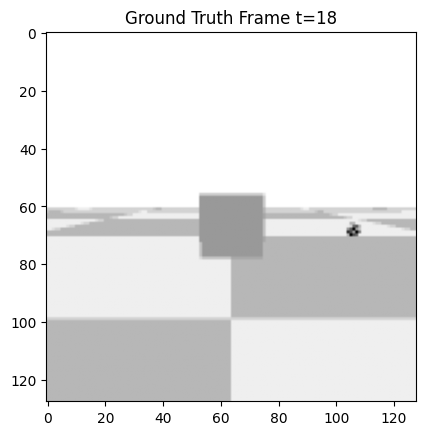

In [ ]:
print("Predicted frame shape:", pred_frames.shape)
print("Predicted min:", pred_frames.min())
print("Predicted max:", pred_frames.max())

import matplotlib.pyplot as plt
t = pred_frames.shape[1] - 1
plt.imshow(np.clip(pred_frames[0, t, :, :, 0], 0, 1), cmap='gray')
plt.title(f"Predicted Frame t={t}")
plt.show()

plt.imshow(video_tensor[0, t, :, :, 0].cpu(), cmap='gray')
plt.title(f"Ground Truth Frame t={t}")
plt.show()